# SPICE vs PHOEBE bolometric light-curve comparison

Loads the per-grid-point pickles produced by `check_phoebe_eclipses.py` and
compares the bolometric eclipse light curves from SPICE against PHOEBE.

Each pickle contains:
- `fluxes_phoebe` — PHOEBE bolometric flux (linear, erg/s/cm^2)
- `bol_lum`       — SPICE AB magnitudes already zeroed at `t=0`
- `times`         — sample times in days, primary then secondary eclipse
- scalar params: `inclination`, `period`, `q`, `ecc`, `primary_mass`, `secondary_mass`, `sma`, `n_times`

In [15]:
import glob
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

%matplotlib inline

In [8]:
# Directory of pickles produced by check_phoebe_eclipses.py (--output_path).
# Override here if your run wrote somewhere else.
RESULTS_DIR = Path('/home/100/mj8805/scr_y89/spice_eclipses/167571765')

pkl_files = sorted(glob.glob(str(RESULTS_DIR / 'eclipses_*.pkl')))
print(f'{len(pkl_files)} pickle(s) under {RESULTS_DIR}')

24 pickle(s) under /home/100/mj8805/scr_y89/spice_eclipses/167571765


In [10]:
def phoebe_flux_to_mag(flux):
    """PHOEBE bolometric flux -> magnitude, zeroed at the first sample."""
    flux = np.asarray(flux, dtype=float)
    mag = -2.5 * np.log10(flux)
    return mag - mag[0]


def load_run(path):
    """Load one pickle and pull out everything needed for a comparison plot."""
    with open(path, 'rb') as f:
        data = pickle.load(f)
    times = np.asarray(data['times'])
    spice_mag = np.asarray(data['bol_lum'])  # already zeroed in check_phoebe_eclipses.py
    phoebe_mag = phoebe_flux_to_mag(data['fluxes_phoebe'])
    return {
        'path': path,
        'times': times,
        'spice_mag': spice_mag,
        'phoebe_mag': phoebe_mag,
        'residual': spice_mag - phoebe_mag,
        'inclination': float(data['inclination']),
        'period': float(data['period']),
        'q': float(data['q']),
        'ecc': float(data['ecc']),
        'primary_mass': float(data['primary_mass']),
        'secondary_mass': float(data['secondary_mass']),
    }

## Single grid point

Quick visual check on one pickle: PHOEBE vs SPICE bolometric light curves and the residual.

In [11]:
assert pkl_files, f'No pickles in {RESULTS_DIR}; run check_phoebe_eclipses.py first.'
example = load_run(pkl_files[0])
print(os.path.basename(example['path']))
print(f"incl={example['inclination']}, P={example['period']} d, "
      f"q={example['q']}, ecc={example['ecc']}, m1={example['primary_mass']}")

Connection to online passbands at https://tables.phoebe-project.org could not be established.  Check your internet connection or try again later (can manually call phoebe.list_online_passbands(refresh=True) to retry).  If the problem persists and you're using a Mac, you may need to update openssl (see https://phoebe-project.org/help/faq). Original error from urlopen: URLError <urlopen error [Errno 101] Network is unreachable>


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


eclipses_incl_80.0_period_2.0_q_0.5_ecc_0.2_primary_mass_1.0.pkl
incl=80.0, P=2.0 d, q=0.5, ecc=0.2, m1=1.0


In [12]:
# check_phoebe_eclipses.py concatenates [primary-eclipse window, secondary-eclipse window],
# so the time axis isn't monotonic. Split it back into the two windows for plotting.
half = len(example['times']) // 2
t_primary = example['times'][:half]
t_secondary = example['times'][half:]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex='col', sharey='row',
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05, 'wspace': 0.15})

for ax_lc, ax_res, t, label in (
    (axes[0, 0], axes[1, 0], t_primary, 'Primary eclipse'),
    (axes[0, 1], axes[1, 1], t_secondary, 'Secondary eclipse'),
):
    sl = slice(0, half) if label == 'Primary eclipse' else slice(half, None)
    ax_lc.plot(t, example['phoebe_mag'][sl], 'o-', label='PHOEBE', color='black')
    ax_lc.plot(t, example['spice_mag'][sl], 's--', label='SPICE', color='firebrick')
    ax_lc.invert_yaxis()
    ax_lc.set_title(label)
    ax_lc.grid(alpha=0.3)

    ax_res.axhline(0, color='gray', lw=0.7)
    ax_res.plot(t, example['residual'][sl], 'o-', color='steelblue')
    ax_res.set_xlabel('Time [days]')
    ax_res.grid(alpha=0.3)

axes[0, 0].set_ylabel(r'$\Delta$ mag (zeroed at $t_0$)')
axes[1, 0].set_ylabel('SPICE - PHOEBE [mag]')
axes[0, 0].legend(loc='best')
fig.suptitle(
    f"incl={example['inclination']}, P={example['period']} d, "
    f"q={example['q']}, ecc={example['ecc']}, m1={example['primary_mass']}"
)
plt.show()

print(f"max |residual| = {np.nanmax(np.abs(example['residual'])):.4e} mag")
print(f"rms residual   = {np.sqrt(np.nanmean(example['residual']**2)):.4e} mag")

max |residual| = 1.0817e-02 mag
rms residual   = 8.0671e-03 mag


## Grid summary

Aggregate residual statistics across every pickle in `RESULTS_DIR`.

In [13]:
runs = []
for path in tqdm(pkl_files):
    try:
        runs.append(load_run(path))
    except Exception as exc:
        print(f'[skip] {os.path.basename(path)}: {exc}')

summary = pd.DataFrame([
    {
            'inclination': r['inclination'],
            'period': r['period'],
            'q': r['q'],
            'ecc': r['ecc'],
            'primary_mass': r['primary_mass'],
            'secondary_mass': r['secondary_mass'],
            'max_abs_residual': float(np.nanmax(np.abs(r['residual']))),
            'rms_residual': float(np.sqrt(np.nanmean(r['residual']**2))),
            'mean_residual': float(np.nanmean(r['residual'])),
    }
    for r in runs
])
summary.head()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:23<00:00,  1.03it/s]


,inclination,period,q,ecc,primary_mass,secondary_mass,max_abs_residual,rms_residual,mean_residual
0,80.0,2.0,0.5,0.2,1.0,0.5,0.010817,0.008067,0.007185
1,80.0,2.0,1.0,0.0,1.0,1.0,0.011131,0.006842,0.005609
2,80.0,2.0,1.0,0.2,1.0,1.0,0.010090,0.006827,0.005924
3,90.0,12.8,0.5,0.0,1.0,0.5,0.019124,0.011296,0.009415
4,90.0,12.8,0.5,0.2,1.0,0.5,0.022285,0.012333,0.010197


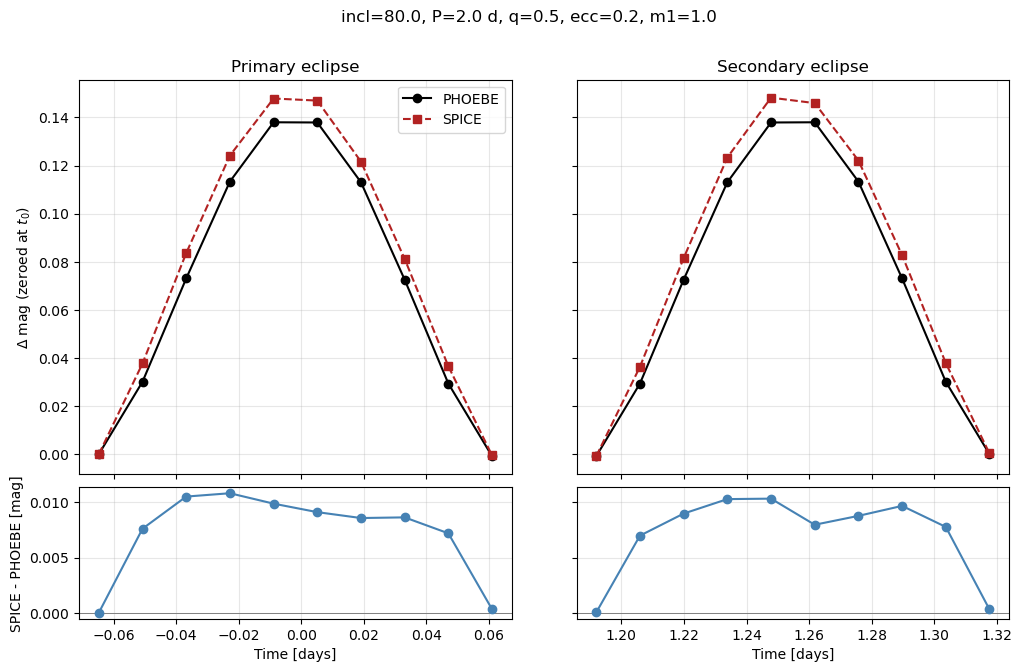

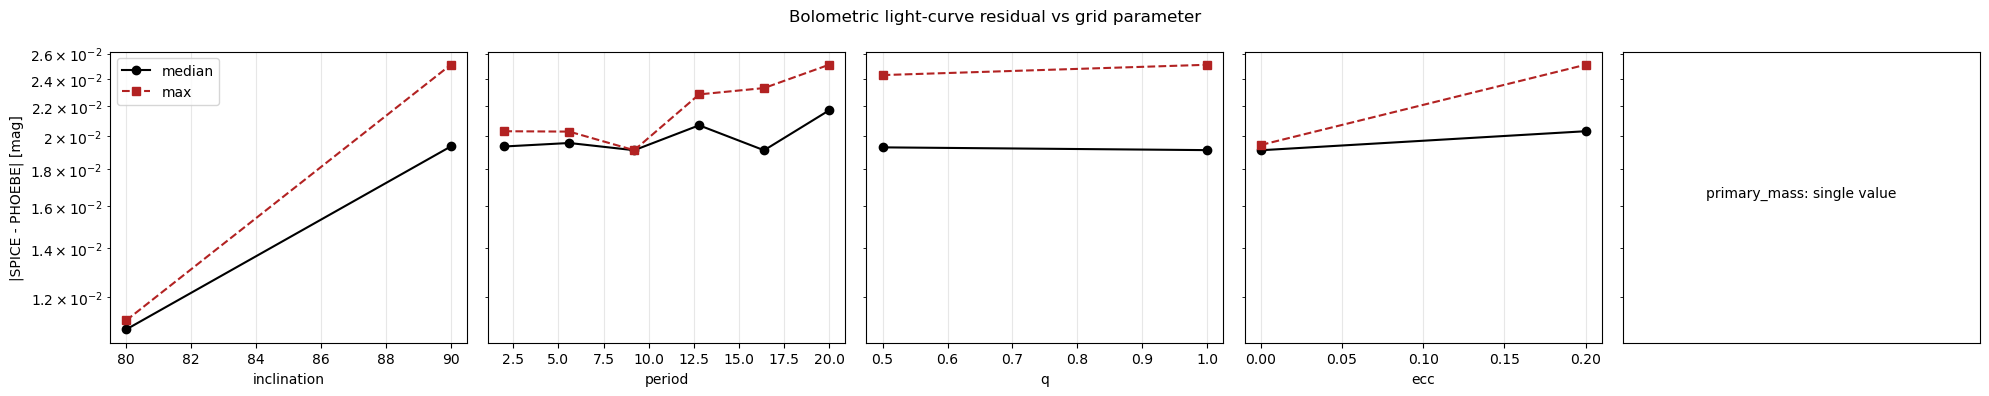

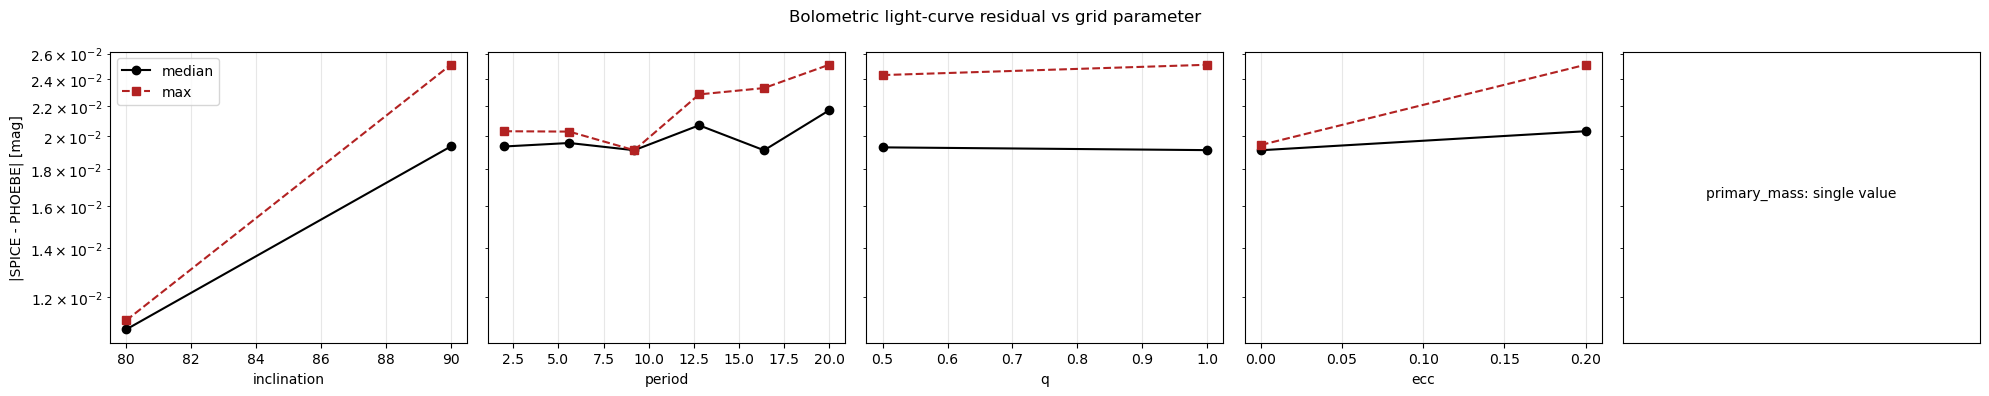

In [16]:
# Median / max residual as a function of each parameter — quick eyeball test
# for which axes drive the disagreement between the two codes.
params = ['inclination', 'period', 'q', 'ecc', 'primary_mass']
fig, axes = plt.subplots(1, len(params), figsize=(4 * len(params), 4), sharey=True)

for ax, param in zip(axes, params):
    g = summary.groupby(param)['max_abs_residual'].agg(['median', 'max']).reset_index()
    if len(g) <= 1:
        ax.text(0.5, 0.5, f'{param}: single value', transform=ax.transAxes, ha='center')
        ax.set_xticks([])
        continue
    ax.plot(g[param], g['median'], 'o-', label='median', color='black')
    ax.plot(g[param], g['max'], 's--', label='max', color='firebrick')
    ax.set_xlabel(param)
    ax.set_yscale('log')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('|SPICE - PHOEBE| [mag]')
axes[0].legend(loc='best')
fig.suptitle('Bolometric light-curve residual vs grid parameter')
plt.tight_layout()
plt.show()

In [17]:
# Worst grid points by max |residual| — useful for picking pickles to re-plot above.
summary.sort_values('max_abs_residual', ascending=False).head(10)

,inclination,period,q,ecc,primary_mass,secondary_mass,max_abs_residual,rms_residual,mean_residual
17,90.0,20.0,1.0,0.2,1.0,1.0,0.025099,0.012760,0.010046
15,90.0,20.0,0.5,0.2,1.0,0.5,0.024289,0.012600,0.010066
8,90.0,16.4,0.5,0.2,1.0,0.5,0.023308,0.012450,0.010123
6,90.0,12.8,1.0,0.2,1.0,1.0,0.022843,0.012385,0.010144
4,90.0,12.8,0.5,0.2,1.0,0.5,0.022285,0.012333,0.010197
11,90.0,2.0,0.5,0.2,1.0,0.5,0.020318,0.012950,0.011177
21,90.0,5.6,1.0,0.2,1.0,1.0,0.020294,0.012292,0.010460
13,90.0,2.0,1.0,0.2,1.0,1.0,0.020052,0.012714,0.010930
19,90.0,5.6,0.5,0.2,1.0,0.5,0.019989,0.012332,0.010523
10,90.0,2.0,0.5,0.0,1.0,0.5,0.019449,0.011411,0.009861


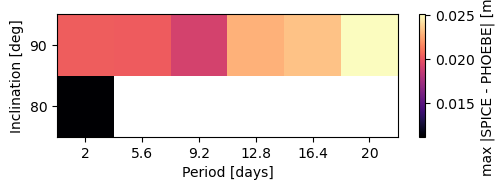

In [18]:
# Inclination x period heatmap of the max residual (collapses q/ecc/m1 by max).
if {'inclination', 'period'}.issubset(summary.columns) and len(summary) > 1:
    pivot = summary.pivot_table(
        index='inclination', columns='period',
        values='max_abs_residual', aggfunc='max',
    )
    fig, ax = plt.subplots(figsize=(1 + 0.7 * pivot.shape[1], 1 + 0.5 * pivot.shape[0]))
    im = ax.imshow(pivot.values, aspect='auto', origin='lower',
                   extent=(0, pivot.shape[1], 0, pivot.shape[0]),
                   cmap='magma')
    ax.set_xticks(np.arange(pivot.shape[1]) + 0.5)
    ax.set_xticklabels([f'{c:g}' for c in pivot.columns])
    ax.set_yticks(np.arange(pivot.shape[0]) + 0.5)
    ax.set_yticklabels([f'{r:g}' for r in pivot.index])
    ax.set_xlabel('Period [days]')
    ax.set_ylabel('Inclination [deg]')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('max |SPICE - PHOEBE| [mag]')
    plt.tight_layout()
    plt.show()
else:
    print('Need >1 (inclination, period) grid points for a heatmap.')